# PyTorch Beginner's Guide with Practical Example
## Predicting House Prices using a Neural Network

This notebook teaches PyTorch fundamentals using a real-world house price prediction task. No deep theory—just practical, working code!

**What we'll learn:**
1. Loading and exploring data with pandas
2. Preparing data for PyTorch
3. Creating a simple Neural Network
4. Training the model
5. Making predictions
6. Evaluating performance

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Step 1: Import Libraries

Let's start by importing everything we need:

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

✅ All libraries imported successfully!
PyTorch version: 2.11.0+cpu


## Step 2: Load and Explore the Data

We're using a dataset with:
- **square_footage**: Size of house (input feature)
- **bedrooms**: Number of bedrooms (input feature)
- **bathrooms**: Number of bathrooms (input feature)
- **price**: House price we want to predict (target)

In [25]:
# Load the CSV file
df = pd.read_csv('/content/drive/MyDrive/AI/house_prices.csv')

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset statistics:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (200, 4)

First 5 rows:
   square_footage  bedrooms  bathrooms          price
0     1998.528380         4   3.883572  625866.004306
1     3842.285781         3   3.716052  844497.666959
2     3142.380614         1   1.587373  589729.093086
3     2715.707149         4   1.208084  633398.261516
4     1299.259649         4   1.302334  428561.468830

Dataset statistics:
       square_footage    bedrooms   bathrooms          price
count      200.000000  200.000000  200.000000     200.000000
mean      2348.819946    3.035000    2.599089  582260.756964
std        943.652580    1.440189    0.937223  155175.667506
min        817.670775    1.000000    1.032513  227494.135107
25%       1531.463727    2.000000    1.840203  464755.259513
50%       2382.356010    3.000000    2.679013  584427.591592
75%       3221.950771    4.000000    3.439374  707729.082233
max       3958.038197    5.000000    3.999153  916014.348938

Missing values:
square_footage    0
bedrooms          0
bathrooms 

## Step 3: Prepare Data for PyTorch

We need to:
1. **Separate features (X) and target (y)**
2. **Normalize the data** (important for neural networks!)
3. **Split into train and test sets**
4. **Convert to PyTorch tensors**

In [26]:
# Step 3a: Separate features and target
X = df[['square_footage', 'bedrooms', 'bathrooms']].values
y = df[['price']].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFirst 3 samples (features):")
print(X[:3])

Features shape: (200, 3)
Target shape: (200, 1)

First 3 samples (features):
[[1.99852838e+03 4.00000000e+00 3.88357169e+00]
 [3.84228578e+03 3.00000000e+00 3.71605193e+00]
 [3.14238061e+03 1.00000000e+00 1.58737340e+00]]


In [27]:
# Step 3b: Normalize the data using StandardScaler
# Why? Neural networks train faster with normalized data!

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_normalized = scaler_X.fit_transform(X)
y_normalized = scaler_y.fit_transform(y)

print("After normalization:")
print(f"X mean: {X_normalized.mean():.4f}, std: {X_normalized.std():.4f}")
print(f"y mean: {y_normalized.mean():.4f}, std: {y_normalized.std():.4f}")

After normalization:
X mean: -0.0000, std: 1.0000
y mean: 0.0000, std: 1.0000


In [28]:
# Step 3c: Split into train (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y_normalized, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 160
Test set size: 40


In [29]:
# Step 3d: Convert numpy arrays to PyTorch tensors
# Tensors are PyTorch's version of arrays—they run on GPUs!

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

print(f"X_train tensor shape: {X_train_tensor.shape}")
print(f"y_train tensor shape: {y_train_tensor.shape}")
print(f"\nFirst tensor sample:")
print(f"Features: {X_train_tensor[0]}")
print(f"Price: {y_train_tensor[0]}")

X_train tensor shape: torch.Size([160, 3])
y_train tensor shape: torch.Size([160, 1])

First tensor sample:
Features: tensor([-1.2515,  1.3678,  1.3292])
Price: tensor([-0.5353])


In [30]:
print(type(X_train_tensor))

<class 'torch.Tensor'>


In [31]:
# Step 3e: Create DataLoaders for batch processing
# DataLoader automatically creates batches and shuffles data
batch_size = 16
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Number of batches per epoch: {len(train_loader)}")
print(f"Batch size: {batch_size}")

# Show first batch
for X_batch, y_batch in train_loader:
    print(f"\nFirst batch - Features shape: {X_batch.shape}")
    print(f"First batch - Target shape: {y_batch.shape}")
    break

Number of batches per epoch: 10
Batch size: 16

First batch - Features shape: torch.Size([16, 3])
First batch - Target shape: torch.Size([16, 1])


## Step 4: Define the Neural Network

Think of a neural network like a simple factory:
- **Input layer**: Gets 3 features (square footage, bedrooms, bathrooms)
- **Hidden layers**: Learn patterns in the data
- **Output layer**: Predicts 1 price value

```
Input (3) → Hidden (16) → Hidden (8) → Output (1)
```

In [32]:
# Define the Neural Network
class HousePricePredictor(nn.Module):
    def __init__(self):
        super().__init__()

        # Layer 1: 3 inputs → 16 neurons
        self.layer1 = nn.Linear(3, 16)

        # Layer 2: 16 neurons → 8 neurons
        self.layer2 = nn.Linear(16, 8)

        # Layer 3: 8 neurons → 1 output (price)
        self.layer3 = nn.Linear(8, 1)

        # Activation function (ReLU = Rectified Linear Unit)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Forward pass: input → layer1 → ReLU → layer2 → ReLU → layer3
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

# Create the model
model = HousePricePredictor()
print("Model created!")
print("\nModel architecture:")
print(model)

Model created!

Model architecture:
HousePricePredictor(
  (layer1): Linear(in_features=3, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)


## Step 5: Setup Training Configuration

We need three things:
1. **Loss function**: MSE (Mean Squared Error) - measures how wrong predictions are
2. **Optimizer**: Adam - adjusts weights to minimize loss
3. **Learning rate**: How big each adjustment step is (0.001 is typical)

In [38]:
# Loss function: MSE (regression task)
criterion = nn.MSELoss()

# Optimizer: Adam (popular choice for neural networks)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("✅ Loss function: MSE Loss")
print("✅ Optimizer: Adam (lr=0.001)")
print(f"✅ Model parameters: {sum(p.numel() for p in model.parameters())} total weights")

✅ Loss function: MSE Loss
✅ Optimizer: Adam (lr=0.001)
✅ Model parameters: 209 total weights


## Step 6: Train the Model

Training loop:
1. Forward pass: predict prices
2. Calculate loss
3. Backward pass: compute gradients
4. Update weights

We repeat this for 100 epochs (full passes through the data)

In [39]:
# Training loop
num_epochs = 100
train_losses = []

for epoch in range(num_epochs):
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        # Step 1: Forward pass (predict)
        predictions = model(X_batch)

        # Step 2: Calculate loss
        loss = criterion(predictions, y_batch)

        # Step 3: Backward pass (compute gradients)
        optimizer.zero_grad()  # Clear old gradients
        loss.backward()        # Compute new gradients

        # Step 4: Update weights
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")

print("\n✅ Training complete!")

Epoch [20/100], Loss: 0.033018
Epoch [40/100], Loss: 0.021394
Epoch [60/100], Loss: 0.017960
Epoch [80/100], Loss: 0.016601
Epoch [100/100], Loss: 0.015270

✅ Training complete!


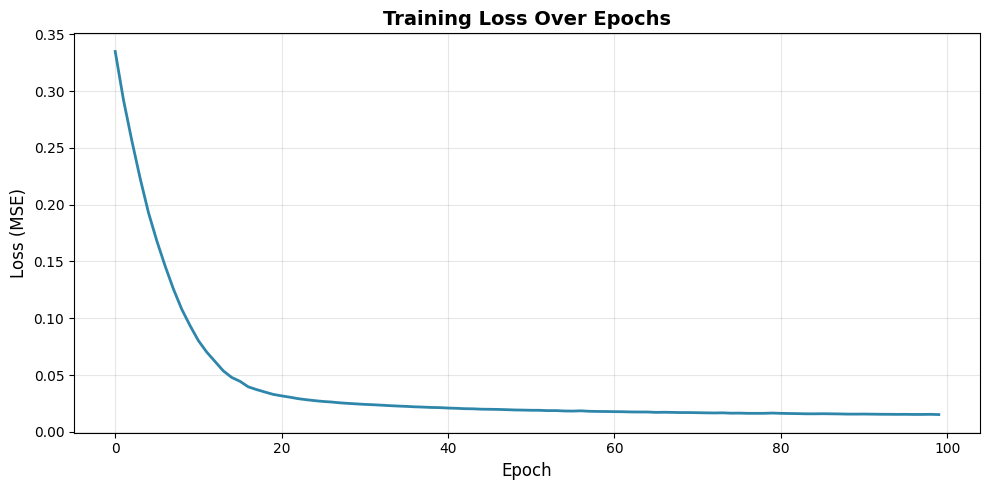

Initial loss: 0.334790
Final loss: 0.015270
Loss reduction: 95.4%


In [40]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, linewidth=2, color='#2E86AB')
plt.title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Initial loss: {train_losses[0]:.6f}")
print(f"Final loss: {train_losses[-1]:.6f}")
print(f"Loss reduction: {((train_losses[0] - train_losses[-1]) / train_losses[0] * 100):.1f}%")

## Step 7: Make Predictions on Test Data

Now let's see how well our trained model performs on unseen data!

In [41]:
# Put model in evaluation mode (disables dropout, batch norm updates)
model.eval()

with torch.no_grad():  # Disable gradient computation for speed
    y_pred = model(X_test_tensor)

# Convert predictions back to numpy
y_pred_np = y_pred.numpy()
y_test_np = y_test_tensor.numpy()

print("Test Set Predictions vs Actual (normalized values):")
print("="*50)
for i in range(min(10, len(y_test_np))):
    print(f"Sample {i+1}: Predicted = {y_pred_np[i][0]:7.4f}, Actual = {y_test_np[i][0]:7.4f}")

Test Set Predictions vs Actual (normalized values):
Sample 1: Predicted =  0.4754, Actual =  0.3598
Sample 2: Predicted = -1.4305, Actual = -1.6566
Sample 3: Predicted =  0.6048, Actual =  0.8028
Sample 4: Predicted = -1.2683, Actual = -1.3645
Sample 5: Predicted = -1.1317, Actual = -1.1696
Sample 6: Predicted =  1.8563, Actual =  2.1562
Sample 7: Predicted =  1.3076, Actual =  1.2507
Sample 8: Predicted =  1.4374, Actual =  1.7485
Sample 9: Predicted =  0.3709, Actual =  0.4043
Sample 10: Predicted =  1.1388, Actual =  1.1159


## Step 8: Evaluate Performance

Calculate metrics to measure how good our predictions are:

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate metrics on normalized data
mse = mean_squared_error(y_test_np, y_pred_np)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_np, y_pred_np)
r2 = r2_score(y_test_np, y_pred_np)

print("Model Performance Metrics (on normalized data):")
print("="*50)
print(f"MSE (Mean Squared Error):  {mse:.6f}")
print(f"RMSE (Root Mean Squared):  {rmse:.6f}")
print(f"MAE (Mean Absolute Error): {mae:.6f}")
print(f"R² Score:                  {r2:.4f}")
print("\nR² Interpretation:")
print(f"  - R² = 0: Model is terrible")
print(f"  - R² = 1: Model is perfect")
print(f"  - Your R² = {r2:.4f}: Model explains {r2*100:.1f}% of price variance")

Model Performance Metrics (on normalized data):
MSE (Mean Squared Error):  0.020864
RMSE (Root Mean Squared):  0.144444
MAE (Mean Absolute Error): 0.107022
R² Score:                  0.9819

R² Interpretation:
  - R² = 0: Model is terrible
  - R² = 1: Model is perfect
  - Your R² = 0.9819: Model explains 98.2% of price variance


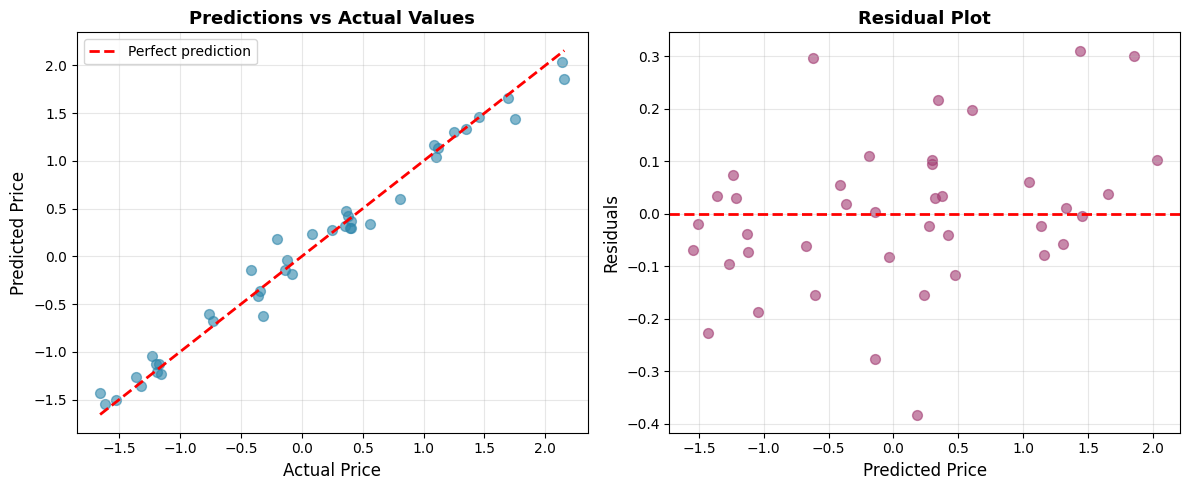

In [43]:
# Visualize predictions vs actual values
plt.figure(figsize=(12, 5))

# Plot 1: Predictions vs Actual
plt.subplot(1, 2, 1)
plt.scatter(y_test_np, y_pred_np, alpha=0.6, color='#2E86AB', s=50)
plt.plot([y_test_np.min(), y_test_np.max()],
         [y_test_np.min(), y_test_np.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.title('Predictions vs Actual Values', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residuals
plt.subplot(1, 2, 2)
residuals = y_test_np - y_pred_np
plt.scatter(y_pred_np, residuals, alpha=0.6, color='#A23B72', s=50)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Price', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 9: Make Predictions with New Data

Let's predict prices for some hypothetical houses!

In [ ]:
# Create new house data (not in training set)
new_houses = pd.DataFrame({
    'square_footage': [1500, 2500, 3500],
    'bedrooms': [3, 4, 5],
    'bathrooms': [2, 2.5, 3.5]
})

print("New houses to predict:")
print(new_houses)
print()

# Normalize using the same scaler
new_houses_normalized = scaler_X.transform(new_houses)
new_houses_tensor = torch.FloatTensor(new_houses_normalized)

# Make predictions
model.eval()
with torch.no_grad():
    predictions_normalized = model(new_houses_tensor).numpy()

# Denormalize predictions back to original scale
predictions_original = scaler_y.inverse_transform(predictions_normalized)

print("\nPrice Predictions:")
print("="*60)
for i, (idx, row) in enumerate(new_houses.iterrows()):
    print(f"House {i+1}:")
    print(f"  Size: {row['square_footage']:.0f} sq ft, "
          f"Beds: {row['bedrooms']}, "
          f"Baths: {row['bathrooms']:.1f}")
    print(f"  Predicted Price: ${predictions_original[i][0]:,.2f}")
    print()

## Step 10: Save and Load the Model

Don't lose your trained model! Let's save it for future use.

In [ ]:
# Save the model
torch.save(model.state_dict(), 'house_price_model.pth')
print("✅ Model saved as 'house_price_model.pth'")

# Load the model
loaded_model = HousePricePredictor()
loaded_model.load_state_dict(torch.load('house_price_model.pth'))
loaded_model.eval()
print("✅ Model loaded successfully!")

# Verify loaded model works
with torch.no_grad():
    test_pred = loaded_model(new_houses_tensor[0:1])
print(f"\nTest prediction from loaded model: {test_pred.item():.6f}")

## Summary 🎯

Congratulations! You now know:

1. **Data Preparation**: Loading CSV, normalization, train-test split
2. **Neural Networks**: Creating layers with `nn.Linear` and activation functions
3. **Training**: Forward pass, loss calculation, backpropagation, weight updates
4. **Evaluation**: Metrics like MSE, RMSE, MAE, R²
5. **Prediction**: Making predictions on new data
6. **Saving/Loading**: Persisting models for later use

### Key Takeaways:
- **Normalize your data** before feeding it to neural networks
- **Use DataLoader** for efficient batch processing
- **Monitor training loss** to ensure your model is learning
- **Evaluate on test data** to measure real performance
- **Save your models** after training!

### Next Steps:
- Try changing the network architecture (more/fewer layers)
- Experiment with different learning rates
- Create your own dataset
- Try classification problems (predicting categories instead of numbers)